# Wire detection using background subtraction

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def get_top_keypoints(kp, des, top_n=200):
    if len(kp) > top_n:
        idx = np.argsort([-k.response for k in kp])[:top_n]
        kp = [kp[i] for i in idx]
        des = des[idx]
    return kp, des

In [2]:
def keypoint_mask(img):
    # Optional pre-step: blur and threshold to isolate dark holes
    
    blurred = cv2.GaussianBlur(img, (3, 3), 0)
    _, holes_mask = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY)

    # Invert so holes become black (ignored)
    keypoint_mask = cv2.bitwise_not(holes_mask)

    return keypoint_mask


In [17]:
# Load the images
img_bg = cv2.imread('background.jpg')
img_content = cv2.imread('content.jpg')

scale_percent = 50  # X0%
new_size = (int(img_bg.shape[1] * scale_percent / 100),
            int(img_bg.shape[0] * scale_percent / 100))
img_bg = cv2.resize(img_bg, new_size, interpolation=cv2.INTER_AREA)
img_content = cv2.resize(img_content, new_size, interpolation=cv2.INTER_AREA)

# Resize (optional, only if needed to match)
# img_bg = cv2.resize(img_bg, (img_content.shape[1], img_content.shape[0]))

# Convert to grayscale
gray_bg = cv2.cvtColor(img_bg, cv2.COLOR_BGR2GRAY)
gray_content = cv2.cvtColor(img_content, cv2.COLOR_BGR2GRAY)

In [31]:
keypoint_mask_bg = keypoint_mask(gray_bg)
keypoint_mask_content = keypoint_mask(gray_content)

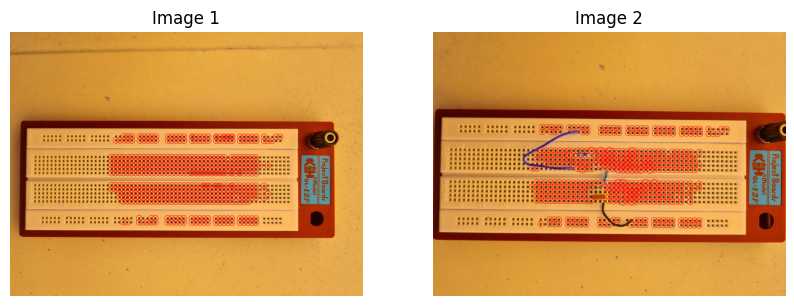

In [32]:
# --- Feature extraction using AKAZE ---
akaze = cv2.AKAZE_create()
kp1, des1 = akaze.detectAndCompute(gray_bg, mask=keypoint_mask_bg)
kp2, des2 = akaze.detectAndCompute(gray_content, mask=keypoint_mask_content)

# Keep only strongest keypoints
kp1, des1 = get_top_keypoints(kp1, des1, top_n=500)
kp2, des2 = get_top_keypoints(kp2, des2, top_n=500)


for kp in kp1:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        radius = int(kp.size * 2)
        cv2.circle(img_bg, (x, y), radius, (255, 0, 0), thickness=3)

for kp in kp2:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        radius = int(kp.size * 2)
        cv2.circle(img_content, (x, y), radius, (255, 0, 0), thickness=3)

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

plt.subplot(1, 2, 1)
plt.imshow(img_bg)
plt.title("Image 1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_content)
plt.title("Image 2")
plt.axis('off')

# Match descriptors using BFMatcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Get matched points
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

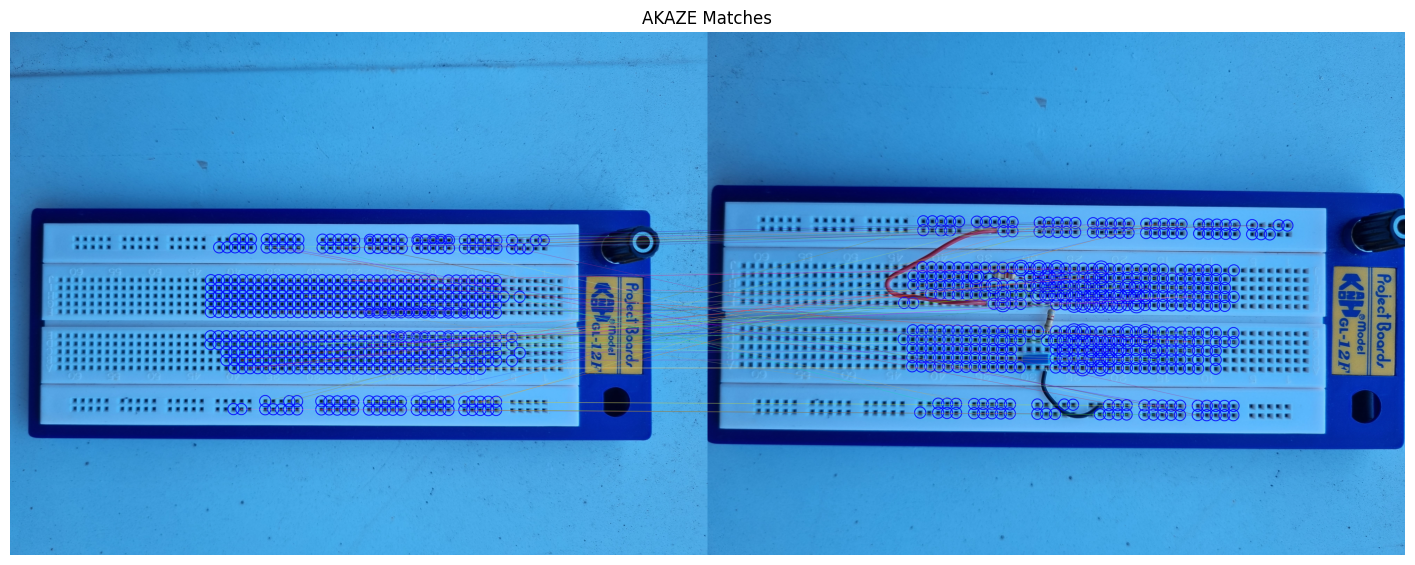

In [33]:
# Visualize matches using cv2.drawMatchesKnn
img_matches = cv2.drawMatchesKnn(
    img_bg, kp1,
    img_content, kp2,
    [[m] for m in matches],  # drawMatchesKnn expects list of lists
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('AKAZE Matches')
plt.axis('off')
plt.show()

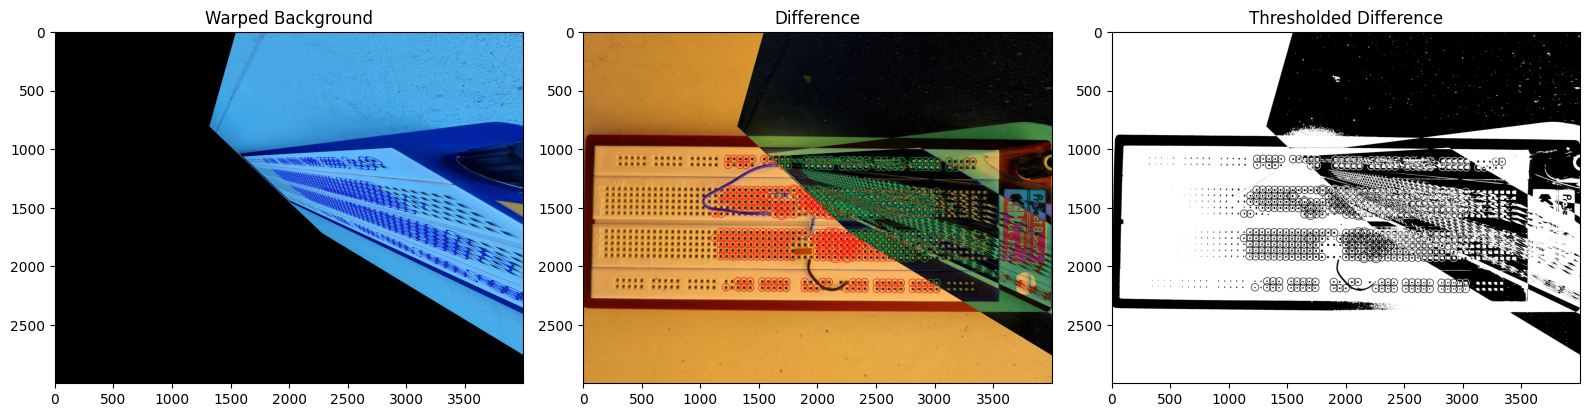

In [34]:


# Find homography matrix
H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Warp background image
warped_bg = cv2.warpPerspective(img_bg, H, (img_content.shape[1], img_content.shape[0]))

# Compute difference
diff = cv2.absdiff(img_content, warped_bg)

# Convert to grayscale and threshold
diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
_, diff_thresh = cv2.threshold(diff_gray, 30, 255, cv2.THRESH_BINARY)

# Morphological cleanup (optional)
kernel = np.ones((3, 3), np.uint8)
diff_clean = cv2.morphologyEx(diff_thresh, cv2.MORPH_OPEN, kernel)

# Show results
plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.title('Warped Background')
plt.imshow(cv2.cvtColor(warped_bg, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title('Difference')
plt.imshow(diff, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Thresholded Difference')
plt.imshow(diff_clean, cmap='gray')
plt.tight_layout()
plt.show()


# ECC

In [ ]:
# === Apply blurring to suppress noise ===
background_blur = cv2.GaussianBlur(gray_bg, (9, 9), 0)
content_blur = cv2.GaussianBlur(gray_content, (9, 9), 0)

cv2.imshow("Mask", background_blur)
cv2.imshow("Reference", content_blur)
cv2.waitKey(0)

# Use ECC to find the best warp matrix
warp_mode = cv2.MOTION_HOMOGRAPHY
warp_matrix = np.eye(3, 3, dtype=np.float32)

criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 200, 1e-6)
cc, warp_matrix = cv2.findTransformECC(background_blur, content_blur, warp_matrix, warp_mode, criteria)




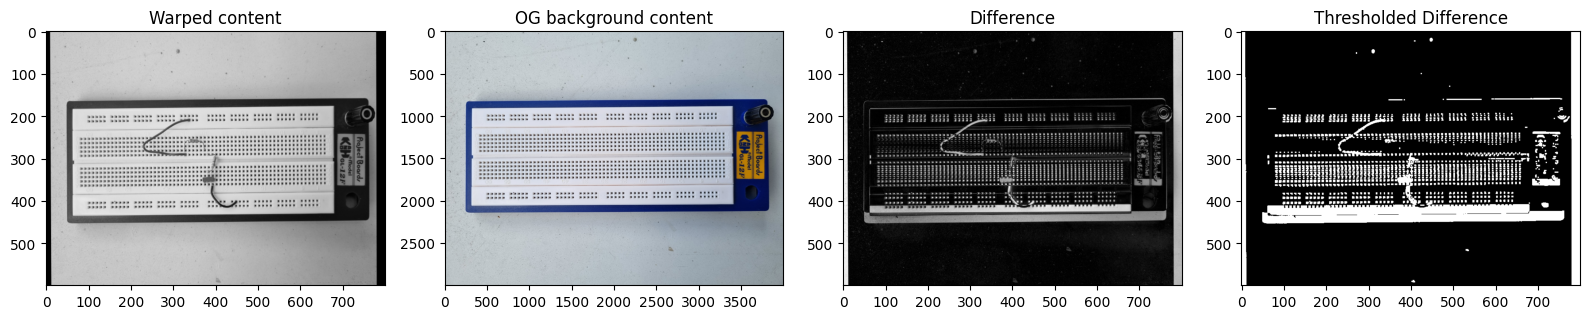

In [8]:
w = gray_bg.shape[1]
h = gray_bg.shape[0]

# Apply warp to img_content
aligned = cv2.warpPerspective(gray_content, warp_matrix, (w, h), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)

diff_gray = cv2.absdiff(gray_bg, aligned)

# Convert to grayscale and threshold
# diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
_, diff_thresh = cv2.threshold(diff_gray, 30, 255, cv2.THRESH_BINARY)

# Morphological cleanup (optional)
kernel = np.ones((3, 3), np.uint8)
diff_clean = cv2.morphologyEx(diff_thresh, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(16, 8))
plt.subplot(1, 4, 1)
plt.title('Warped content')
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))

plt.subplot(1, 4, 2)
plt.title('OG background content')
plt.imshow(cv2.cvtColor(img_bg, cv2.COLOR_BGR2RGB))

plt.subplot(1, 4, 3)
plt.title('Difference')
plt.imshow(diff, cmap='gray')

plt.subplot(1, 4, 4)
plt.title('Thresholded Difference')
plt.imshow(diff_clean, cmap='gray')
plt.tight_layout()
plt.show()

# Find Breaboard frame

In [6]:
# === 3. Find intersections ===
def line_intersection(line1, line2):
    x1, y1, x2, y2 = line1
    x3, y3, x4, y4 = line2
    A1, B1 = y2 - y1, x1 - x2
    C1 = A1 * x1 + B1 * y1
    A2, B2 = y4 - y3, x3 - x4
    C2 = A2 * x3 + B2 * y3
    det = A1 * B2 - A2 * B1
    if det == 0:
        return None  # parallel lines
    x = (B2 * C1 - B1 * C2) / det
    y = (A1 * C2 - A2 * C1) / det
    return [int(x), int(y)]

# Sort corners: [top-left, top-right, bottom-right, bottom-left]
def sort_corners(pts):
    pts = sorted(pts, key=lambda x: x[0] + x[1])  # TL will have smallest sum
    tl = pts[0]
    br = pts[-1]
    tr = min(pts[1:-1], key=lambda x: x[0] - x[1])
    bl = max(pts[1:-1], key=lambda x: x[0] - x[1])
    return np.array([tl, tr, br, bl], dtype=np.float32)

def find_corners(mask):
    # Find contours from mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found in mask")
    largest = max(contours, key=cv2.contourArea)

    # Fit a minimum area rectangle
    rect = cv2.minAreaRect(largest)  # returns (center(x,y), (width, height), angle of rotation)
    box = cv2.boxPoints(rect)        # Get 4 corner points
    box = np.int0(box)               # Convert to integer

    src_pts = sort_corners(box)

    return(src_pts)

# Mask Breadboard Frame

In [4]:
def mask_bb_frame(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Threshold to isolate bright region
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    # Create a mask for flood filling (2 pixels larger than the image)
    h, w = thresh.shape
    floodfill_mask = np.zeros((h + 2, w + 2), np.uint8)

    # Flood fill from (0, 0) and borders
    flood_filled = thresh.copy()
    cv2.floodFill(flood_filled, floodfill_mask, (0, 0), 0)
    cv2.floodFill(flood_filled, floodfill_mask, (w - 1, 0), 0)
    cv2.floodFill(flood_filled, floodfill_mask, (0, h - 1), 0)
    cv2.floodFill(flood_filled, floodfill_mask, (w - 1, h - 1), 0)

    # Now find the largest contour on the cleaned mask
    contours, _ = cv2.findContours(flood_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest = max(contours, key=cv2.contourArea)

    # Draw the mask only for the largest interior component
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest], -1, 255, -1)

    # Use Closing to clean up mask
    kernel = np.ones((5,5),np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

In [41]:
gray = cv2.cvtColor(img_bg, cv2.COLOR_BGR2GRAY)

# Threshold to isolate bright region
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

# Create a mask for flood filling (2 pixels larger than the image)
h, w = thresh.shape
floodfill_mask = np.zeros((h + 2, w + 2), np.uint8)

# Flood fill from (0, 0) and borders
flood_filled = thresh.copy()
cv2.floodFill(flood_filled, floodfill_mask, (0, 0), 0)
cv2.floodFill(flood_filled, floodfill_mask, (w - 1, 0), 0)
cv2.floodFill(flood_filled, floodfill_mask, (0, h - 1), 0)
cv2.floodFill(flood_filled, floodfill_mask, (w - 1, h - 1), 0)

# Now find the largest contour on the cleaned mask
contours, _ = cv2.findContours(flood_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)

# Draw the mask only for the largest interior component
mask = np.zeros_like(gray)
cv2.drawContours(mask, [largest], -1, 255, -1)

# Use Closing to clean up mask
kernel = np.ones((5,5),np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

corners = find_corners(mask)
print(corners)


# === 2. Find edges and Hough lines ===
edges = cv2.Canny(mask, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

# Draw lines for visual debug
line_img = img_content.copy()
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

cv2.imshow("Clean Mask", mask)
cv2.imshow("Threshold", thresh)
cv2.imshow("Flood Filled", flood_filled)
cv2.imshow("Line", line_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Get unique intersection points
intersections = []
for i in range(len(lines)):
    for j in range(i + 1, len(lines)):
        pt = line_intersection(lines[i][0], lines[j][0])
        if pt:
            intersections.append(pt)

# Filter intersections inside the mask
# intersections = [pt for pt in intersections if mask[pt[1], pt[0]] > 0]

# Cluster and get 4 corner points (bounding rect)
intersections_np = np.array(intersections, dtype=np.float32)
rect = cv2.minAreaRect(intersections_np)
box = cv2.boxPoints(rect)
box = np.int0(box)

src_pts = sort_corners(box)

print(src_pts)


[[ 63. 177.]
 [ 63. 411.]
 [ 63. 411.]
 [ 63. 177.]]
[[ 63. 177.]
 [ 63. 411.]
 [ 63. 411.]
 [ 63. 177.]]


In [7]:
mask_bg = mask_bb_frame(image=img_bg)
mask_content = mask_bb_frame(image=img_content)
src_pts = find_corners(mask_content)
dst_pts = find_corners(mask_bg)

print(src_pts)
print(dst_pts)

cv2.imshow("mask_bg", mask_bg)
cv2.imshow("mask_content", mask_content)
cv2.waitKey(0)

[[ 52. 189.]
 [ 52. 430.]
 [692. 430.]
 [692. 189.]]
[[ 60. 181.]
 [ 62. 412.]
 [679. 408.]
 [677. 177.]]


-1

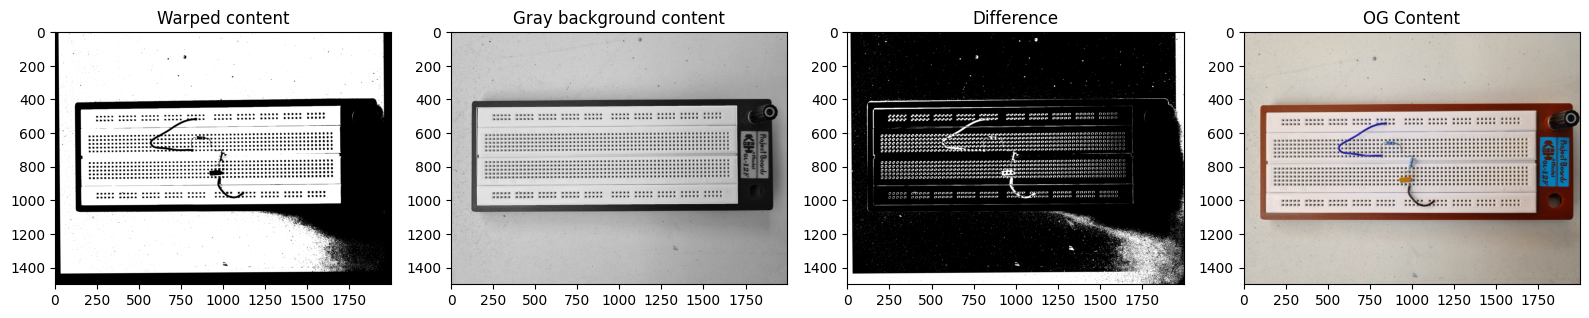

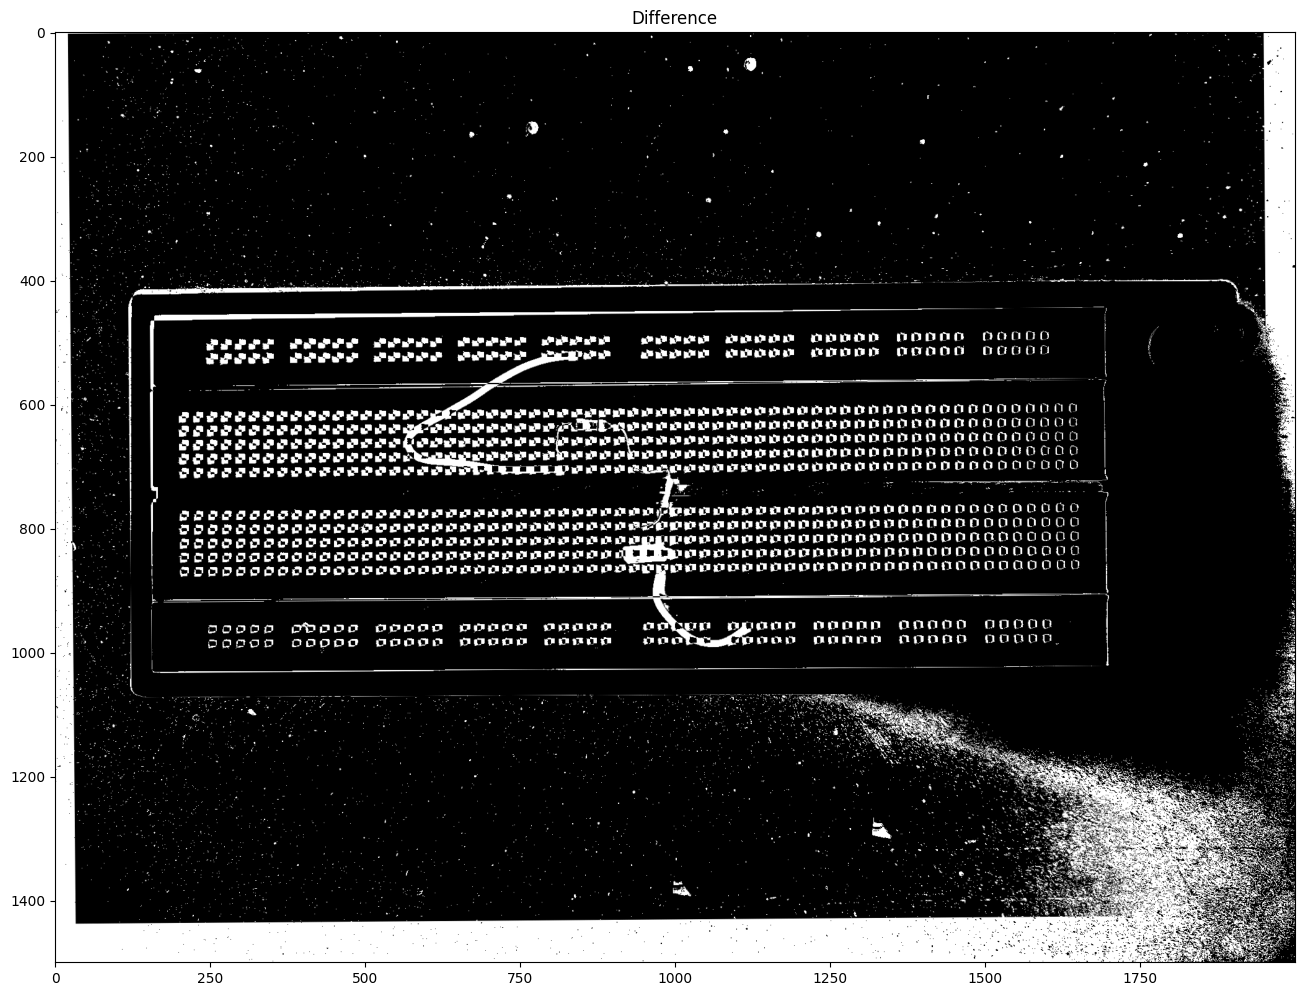

In [ ]:
gray_bg = cv2.cvtColor(img_bg, cv2.COLOR_BGR2GRAY)

# Threshold to isolate bright region
_, thresh_bg = cv2.threshold(gray_bg, 150, 255, cv2.THRESH_BINARY)

gray_content = cv2.cvtColor(img_content, cv2.COLOR_BGR2GRAY)

# Threshold to isolate bright region
_, thresh_content = cv2.threshold(gray_content, 150, 255, cv2.THRESH_BINARY)

mask_bg = mask_bb_frame(image=img_bg)
mask_content = mask_bb_frame(image=img_content)
src_pts = find_corners(mask_content)
dst_pts = find_corners(mask_bg)

# === 5. Warp content image ===
H = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped_content = cv2.warpPerspective(thresh_content, H, (img_bg.shape[1], img_bg.shape[0]))

# === 6. Subtract images ===
diff = cv2.absdiff(thresh_bg, warped_content)

# === 7. Visual Output ===
cv2.drawContours(gray_content, [np.int32(src_pts)], -1, (0, 0, 255), 2)
cv2.drawContours(gray_bg, [np.int32(dst_pts)], -1, (255, 0, 0), 2)

plt.figure(figsize=(16, 8))
plt.subplot(1, 4, 1)
plt.title('Warped content')
plt.imshow(warped_content, cmap='gray')

plt.subplot(1, 4, 2)
plt.title('Gray background content')
plt.imshow(thresh_bg, cmap='gray')

plt.subplot(1, 4, 3)
plt.title('Difference')
plt.imshow(diff, cmap='gray')

plt.subplot(1, 4, 4)
plt.title('OG Content')
plt.imshow(img_content, cmap='gray')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 16))
plt.title('Difference')
plt.imshow(diff, cmap='gray')
plt.show()